In [1]:
import sys
import os
from google.colab import drive

# Mount drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Import utils using the reliable method
project_path = '/content/drive/MyDrive/PulseWatch-AI'
import importlib.util
spec = importlib.util.spec_from_file_location("utils", f"{project_path}/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["utils"] = utils
spec.loader.exec_module(utils)

# Now import everything from utils
from utils import *

print("Utils loaded successfully!")

Mounted at /content/drive
Utils loaded successfully!


📊 Found 5361 total files
🔄 Processing first 20 files with labels...



Processing: 100%|██████████| 20/20 [00:37<00:00,  1.85s/it]



✅ FEATURE EXTRACTION COMPLETE
📊 Successfully processed: 19 files
📈 Total columns: 20

🔍 Column names:
['file_name', 'dataset', 'subject_id', 'num_beats', 'mean_hr', 'sdnn', 'rmssd', 'pnn50', 'mean_rr', 'min_rr', 'max_rr', 'mean_pp', 'std_pp', 'mean_amplitude', 'std_amplitude', 'age', 'gender', 'systolic_bp', 'diastolic_bp', 'health_label']

📊 First 5 records:
     file_name dataset subject_id  num_beats    mean_hr        sdnn  \
0  p080737.mat   MIMIC    p080737          9  54.446461  203.007389   
1  p080726.mat   MIMIC    p080726          9  53.523640    6.244998   
2  p064377.mat   MIMIC    p064377          7  39.439089  269.692829   
3  p074618.mat   MIMIC    p074618         10  55.601318  146.226950   
4  p074546.mat   MIMIC    p074546         11  67.084079   14.221111   

        rmssd      pnn50      mean_rr  min_rr  max_rr      mean_pp  \
0  299.607362  75.000000  1102.000000   832.0  1528.0   941.600000   
1    4.276180   0.000000  1121.000000  1112.0  1128.0  1115.000000   


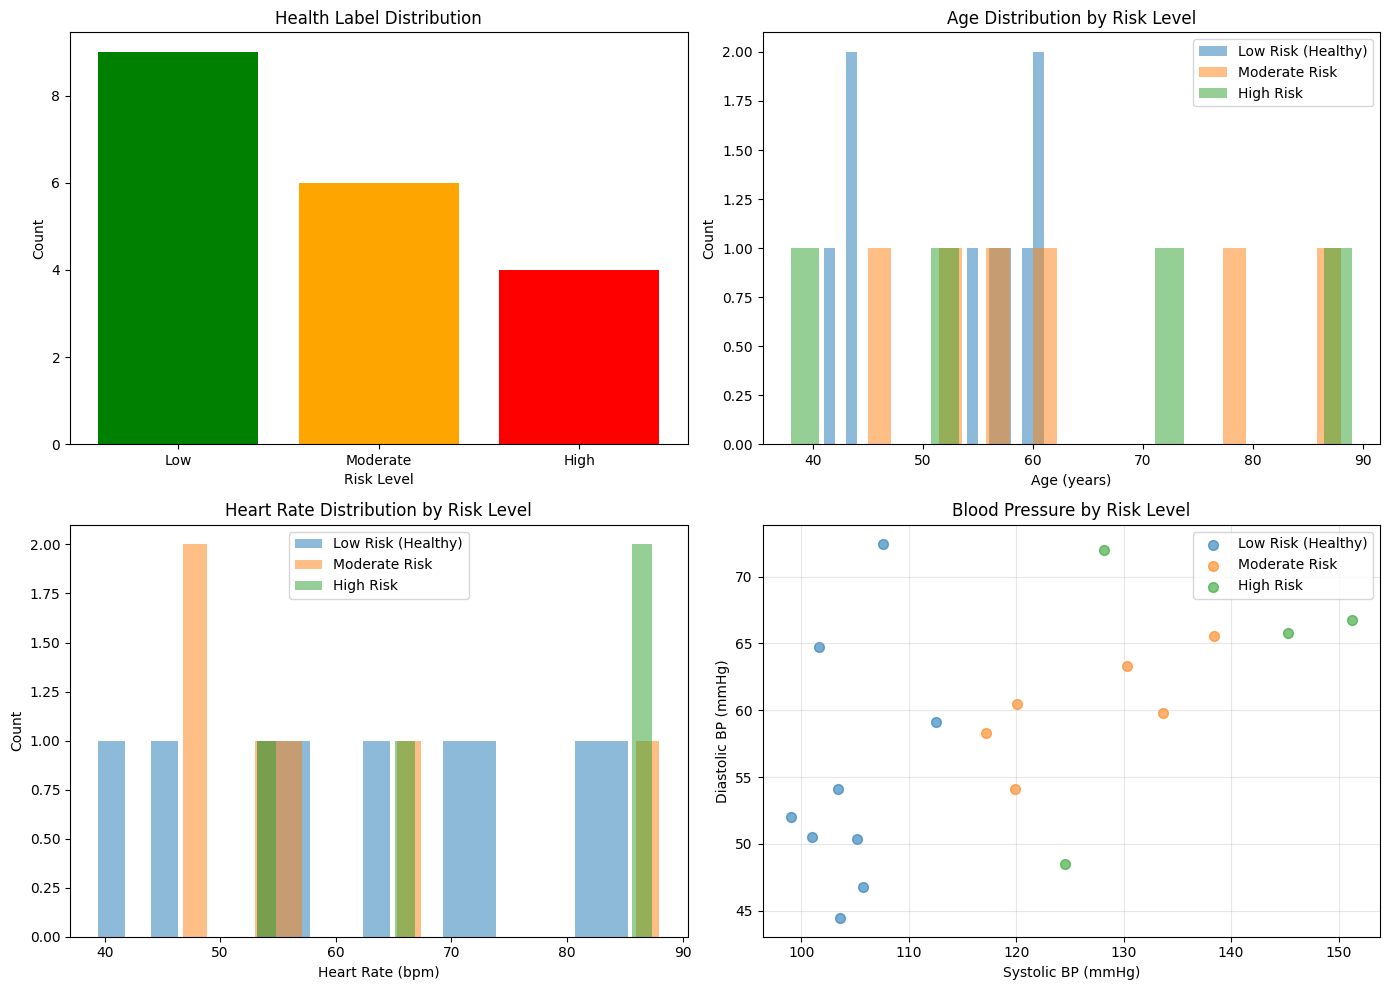

In [ ]:
import sys
import os
from google.colab import drive
import glob
import pandas as pd
from tqdm import tqdm
import numpy as np
import h5py

# LOAD DATA
paths = setup_paths()

all_files = glob.glob(f"{paths['mimic']}/*.mat") + \
            glob.glob(f"{paths['vitaldb']}/*.mat")

print(f"📊 Found {len(all_files)} total files")
print(f"🔄 Processing first 20 files with labels...\n")

# FEATURE EXTRACTION WITH LABELS
all_features = []

for file_path in tqdm(all_files[:20], desc="Processing"):
    record = extract_features_with_labels(file_path)

    if record is not None:
        all_features.append(record)

# CREATE DATAFRAME
df = pd.DataFrame(all_features)

print("\n" + "=" * 60)
print("✅ FEATURE EXTRACTION COMPLETE")
print("=" * 60)
print(f"📊 Successfully processed: {len(df)} files")
print(f"📈 Total columns: {len(df.columns)}")

if len(df) > 0:
    print("\n🔍 Column names:")
    print(df.columns.tolist())

    print("\n📊 First 5 records:")
    print(df.head())

    print("\n🏷️ LABEL DISTRIBUTION:")
    print("=" * 60)
    label_counts = df['health_label'].value_counts().sort_index()
    label_names = {0: "Low Risk (Healthy)", 1: "Moderate Risk", 2: "High Risk"}

    for label, count in label_counts.items():
        if pd.notna(label):
            percentage = (count / len(df)) * 100
            print(f"Class {int(label)}: {label_names[int(label)]:<25} - {count:3d} samples ({percentage:.1f}%)")

    # Check for missing labels
    missing_labels = df['health_label'].isna().sum()
    if missing_labels > 0:
        print(f"\n⚠️  Missing labels: {missing_labels} samples")

    print("\n📈 Feature statistics (HRV):")
    hrv_cols = ['mean_hr', 'sdnn', 'rmssd', 'pnn50']
    print(df[hrv_cols].describe())

    print("\n🩺 Metadata statistics:")
    metadata_cols = ['age', 'systolic_bp', 'diastolic_bp']
    print(df[metadata_cols].describe())

    # SAVE RESULTS
    csv_path = f"{paths['processed']}/hrv_ppg_features_labeled.csv"
    df.to_csv(csv_path, index=False)
    print(f"\n💾 Saved to: {csv_path}")

    # QUICK VISUALIZATION
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Plot 1: Label distribution
    axes[0, 0].bar(label_counts.index, label_counts.values,
                    color=['green', 'orange', 'red'])
    axes[0, 0].set_xlabel('Risk Level')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Health Label Distribution')
    axes[0, 0].set_xticks([0, 1, 2])
    axes[0, 0].set_xticklabels(['Low', 'Moderate', 'High'])

    # Plot 2: Age distribution by label
    for label in [0, 1, 2]:
        data = df[df['health_label'] == label]['age']
        axes[0, 1].hist(data, alpha=0.5, label=label_names[label], bins=20)
    axes[0, 1].set_xlabel('Age (years)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Age Distribution by Risk Level')
    axes[0, 1].legend()

    # Plot 3: Heart Rate by label
    for label in [0, 1, 2]:
        data = df[df['health_label'] == label]['mean_hr']
        axes[1, 0].hist(data, alpha=0.5, label=label_names[label], bins=20)
    axes[1, 0].set_xlabel('Heart Rate (bpm)')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Heart Rate Distribution by Risk Level')
    axes[1, 0].legend()

    # Plot 4: Blood Pressure scatter
    for label in [0, 1, 2]:
        data = df[df['health_label'] == label]
        axes[1, 1].scatter(data['systolic_bp'], data['diastolic_bp'],
                          alpha=0.6, label=label_names[label], s=50)
    axes[1, 1].set_xlabel('Systolic BP (mmHg)')
    axes[1, 1].set_ylabel('Diastolic BP (mmHg)')
    axes[1, 1].set_title('Blood Pressure by Risk Level')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("\n❌ No features extracted")

In [6]:
print("---root---")
! ls /content/drive/MyDrive/PulseWatch-AI
print("---datasets---")
! ls /content/drive/MyDrive/PulseWatch-AI/datasets/
print("---notebooks---")
! ls /content/drive/MyDrive/PulseWatch-AI/notebooks/

---root---
datasets  models  notebooks  __pycache__  utils.py
---datasets---
metadata  processed  raw
---notebooks---
01_Data_Exploration.ipynb  02_Feature_Extraction.ipynb


In [8]:
# ============================================================
# 📁 CREATE GITHUB FOLDER STRUCTURE
# ============================================================

import os

repo_path = '/content/pulse-watch-ai'

# Create folders
folders = [
    'notebooks',
    'src',
    'docs',
]

for folder in folders:
    folder_path = os.path.join(repo_path, folder)
    os.makedirs(folder_path, exist_ok=True)
    print(f"✅ Created: {folder}/")

print("\n✅ Folder structure created!")

✅ Created: notebooks/
✅ Created: src/
✅ Created: docs/

✅ Folder structure created!
